# Example of predictive power score

Predictive power score provides an alternative to r-squared correlation, when there is non-linearity in the relationship. 

See this [link](https://macrosynergy.com/research/the-predictive-power-score/)

In [ ]:
# Install ppscore if needed`
pip install ppscore

Note: you may need to restart the kernel to use updated packages.


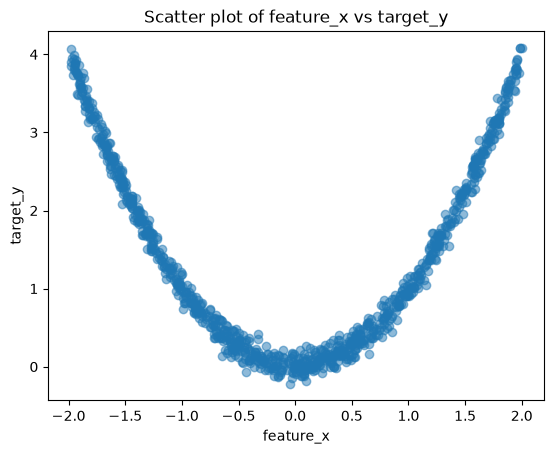

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ppscore as pps

# 1. Create a dummy dataset with a non-linear relationship (y = x^2)
np.random.seed(42)
x = np.random.uniform(-2, 2, 1000)
y = x**2 + np.random.normal(0, 0.1, 1000)

df = pd.DataFrame({'feature_x': x, 'target_y': y})

# plot vs x y
plt.scatter(df['feature_x'], df['target_y'], alpha=0.5)
plt.title('Scatter plot of feature_x vs target_y')
plt.xlabel('feature_x')
plt.ylabel('target_y')
plt.show()

In [4]:
# Calculate r squared
r_squared = df['feature_x'].corr(df['target_y']) ** 2
print(f"R-squared (x predicts y): {r_squared:.4f}")

R-squared (x predicts y): 0.0013


In [5]:
# Calculate a single PPS (Does x predict y?)
# Correlation fails here due to the non-linear relationship, but PPS succeeds.
score_dict = pps.score(df, "feature_x", "target_y")
print(f"PPS (x predicts y): {score_dict['ppscore']:.4f}")

# 3. Generate a full Predictive Power Score Matrix
matrix_df = pps.matrix(df)

# Pivot the matrix for easy reading (similar to a correlation heatmap)
pps_matrix = matrix_df[['x', 'y', 'ppscore']].pivot(columns='x', index='y', values='ppscore')
print("\nPPS Matrix:")
print(pps_matrix)

PPS (x predicts y): 0.8928

PPS Matrix:
x          feature_x  target_y
y                             
feature_x   1.000000       0.0
target_y    0.892838       1.0
